# Explore here

In [35]:
# Your code here
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_regression
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler


from sklearn.neighbors import KNeighborsClassifier

from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import NearestNeighbors

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

import pickle


In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv', sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

**columna objetivo:** `label`
- 0 = Baja calidad
- 1 = Calidad media
- 2 = Alta calidad

## Pasos
1. Entrena el modelo KNN:

- Separa las variables independientes (X) del objetivo (y).
- Divide en conjunto de entrenamiento y prueba (80/20).
- Escala los datos si es necesario (¡muy recomendable con KNN!).
- Entrena el modelo con un valor de k inicial.

2. Evalúa el rendimiento usando:

- accuracy_score
- confusion_matrix
- classification_report

3. Optimización de k. Crea un bucle para probar diferentes valores de k (por ejemplo, de 1 a 20).

- Guarda los resultados en una lista.
- Grafica accuracy vs k para encontrar el mejor valor.

In [5]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(240)

In [7]:
df[df.duplicated()]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.99660,3.17,0.91,9.5,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.99780,3.33,0.83,10.5,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1563,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1564,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1567,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1581,6.2,0.560,0.09,1.70,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5


Aparecen 240 duplicados, pero viendo, son de la columna de quality, por lo que no afectará a nuestros resultados ya que en esta columna es normlal que existan datos duplicados.

In [8]:
df.shape

(1599, 12)

In [9]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [10]:
print(df['quality'].value_counts().sort_index())

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [11]:
#creamos la columna label a partir de la columna quality, con 3 clases: 0 (mala calidad), 1 (calidad media) y 2 (buena calidad)
df['label'] = pd.cut(
    df['quality'],
    bins=[2, 5, 6, 8],
    labels=[0, 1, 2]
)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [12]:
print(df['label'].value_counts().sort_index())

label
0    744
1    638
2    217
Name: count, dtype: int64


In [13]:
df['label2']=pd.cut(
    df['quality'],
    bins=[2, 4, 6, 8],
    labels=[0, 1, 2]
)
print(df['label2'].value_counts().sort_index())

label2
0      63
1    1319
2     217
Name: count, dtype: int64


Aunque la lógica tendría más sentido dividir 3-4 (baja calidad), 5-6 (calidad media) y 7-8 (calidad alta), no lo hacemos así porque el modelo no va a aprender bien, ya que están poco distribuidos los datos. Es por eso que elegimos la `label` primera que hemos realizado en donde divide 3-4-5 (baja calidad), 6 (media) y 7-8 (alta).  

In [14]:
df.drop(columns=['label2'], inplace=True) #borramos la columna label2 porque no la vamos a usar ya que está más desequilibrada, nos quedaremos con label

In [24]:
# 1. Separar X e y
X = df.drop(['quality', 'label'], axis=1)
y = df['label']

# 2. Separar en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print (X_train_scaled.shape, y_train.shape)
print (X_test_scaled.shape, y_test.shape)


(1279, 11) (1279,)
(320, 11) (320,)


In [25]:
#4. Entrenar el modelo
model = KNeighborsClassifier(n_neighbors=5) 
model.fit(X_train_scaled, y_train) 


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [26]:
#5. Predecir
y_pred_test = model.predict(X_test_scaled)
y_pred_train = model.predict(X_train_scaled)

In [28]:
#Evaluar el modelo
accuracy_test = accuracy_score(y_test, y_pred_test)
accuracy_train = accuracy_score(y_train, y_pred_train)

print("Accuracy Test: ", accuracy_test)
print("Accuracy Train: ", accuracy_train)

Accuracy Test:  0.584375
Accuracy Train:  0.746677091477717


Hay bastante diferencia (17 puntos), lo que indica algo de overfitting. Vamos a ver qué pasa si cambiamos el K

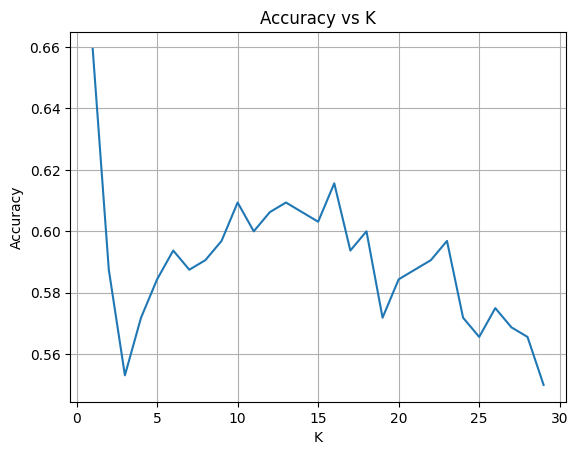

In [31]:
k_range = range(1, 30)
scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    scores.append(knn.score(X_test_scaled, y_test))

#creamos un gráfico para evaluarlo
plt.plot(k_range, scores)
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.grid(True)
plt.title('Accuracy vs K')
plt.show()

([<matplotlib.axis.XTick at 0x119226290>,
 [Text(0, 0, '0'),
  Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(15, 0, '15'),
  Text(20, 0, '20')])

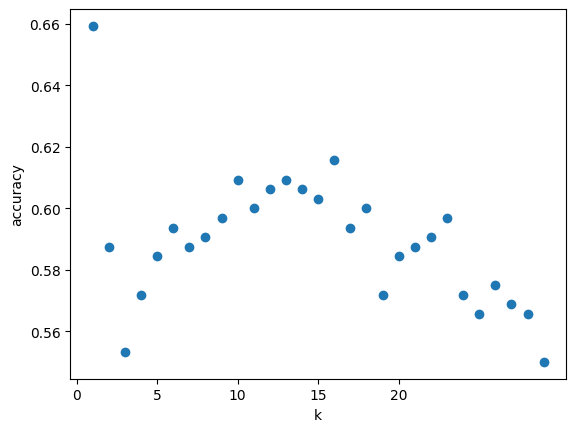

In [33]:
plt.figure()
plt.xlabel('k')
plt.ylabel('accuracy')

plt.scatter(k_range, scores)
plt.xticks([0,5,10,15,20])

En esta gráfica comprobamos que: 
- K=1 tiene 0.66 de accuracy pero con mucho overfitting (memoriza perfectamente el train)
- K=2-4: baja mucho, el punto más bajo junto con 25-30
- K=17: el mejor equilibrio casi un 62%. Elegimos este k para optimizar el modelo

In [34]:
model_final = KNeighborsClassifier(n_neighbors=17)
model_final.fit(X_train_scaled, y_train)

y_pred_final = model_final.predict(X_test_scaled)

print(classification_report(y_test, y_pred_final))
print(confusion_matrix(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.64      0.72      0.68       141
           1       0.52      0.51      0.51       132
           2       0.67      0.47      0.55        47

    accuracy                           0.59       320
   macro avg       0.61      0.56      0.58       320
weighted avg       0.59      0.59      0.59       320

[[101  40   0]
 [ 54  67  11]
 [  2  23  22]]


In [38]:
# Guardamos el modelo
with open('../models/knn_model.pkl', 'wb') as f:
    pickle.dump(model_final, f)

## Conclusiones finales
A partir de un dataset de vinos tintos extraído de "Wine Quality Data Set - UCI", buscabamos crear un modelo que predijera, según las características químicas, la calidad del vino tinto. 

Hemos entrenado el modelo KNN con un K=17, ya que después de analizar un abanico de k, hemos llegado a la conclusión de que iba a ser el valor que mejor accuracy nos iba a dar e iba a predecir mejor. 

Finalmente, el modelo  no generaliza bien, especialmente en las clases extremas. Dado que: un vino de calidad 4 (baja) vs uno de calidad 5 (baja-media) o un vino de calidad 6 (media) vs uno de calidad 7 (alta) son quimicamente muy parecidos. Las fronteras entre clases son muy difusas — no hay un salto químico claro entre "media" y "alta" calidad. KNN con distancias no lo tiene fácil en estos casos.

**Posibles mejoras del modelo**
- Probar otros algoritmos (Random Forest, SVM...) que manejan mejor estas fronteras
- Reducir a solo 2 clases (baja vs alta) para simplificar el problema
- Conseguir más datos de clase 2 que es donde más falla

## RETO: 
Crea una función que reciba valores numéricos y prediga la calidad

In [39]:
def predict_wine_quality(valores):
    # 1. convertir a formato que entienda el modelo
    valores = np.array(valores).reshape(1, -1)
    # 2. escalar
    valores = scaler.transform(valores)
    # 3. predecir
    prediccion = model_final.predict(valores)
    # 4. convertir el número (0,1,2) a texto legible y devolver
    return [f"Este vino probablemente sea de calidad {calidad} 🍷" for calidad in ['Baja', 'Media', 'Alta']][int(prediccion[0])]

In [47]:
predict_wine_quality([7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4])

'Este vino probablemente sea de calidad Baja 🍷'